# Stock Market Return Prediction Using Regression Models

## Problem Statement

The objective of this regression track is to predict the next trading day's
log return using historical stock-market information.

The dataset contains daily OHLCV data for four companies from different
sectors:

- AAPL - Technology
- BA - Industrials
- JPM - Financials
- KO - Consumer Staples

The stocks were selected to represent different market sectors while keeping
the dataset computationally manageable.

The target variable is the next-day log return.


In [1]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("djia4_regression_data.csv")

df.head()

,Date,Open,High,Low,Close,Volume,Ticker
0,04-01-2006,10.73,10.85,10.64,10.71,155225609,AAPL
1,05-01-2006,10.69,10.70,10.54,10.63,112396081,AAPL
2,06-01-2006,10.75,10.96,10.65,10.90,176139334,AAPL
3,09-01-2006,10.96,11.03,10.82,10.86,168861224,AAPL
4,10-01-2006,10.89,11.70,10.83,11.55,570088246,AAPL


In [3]:
df.shape

(12071, 7)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12071 entries, 0 to 12070
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    12071 non-null  str    
 1   Open    12071 non-null  float64
 2   High    12071 non-null  float64
 3   Low     12071 non-null  float64
 4   Close   12071 non-null  float64
 5   Volume  12071 non-null  int64  
 6   Ticker  12071 non-null  str    
dtypes: float64(4), int64(1), str(2)
memory usage: 660.3 KB


In [5]:
df.describe()

,Open,High,Low,Close,Volume
count,12071.000000,12071.000000,12071.000000,12071.000000,1.207100e+04
mean,62.894696,63.459454,62.289549,62.893897,4.533225e+07
std,41.850361,42.113574,41.558776,41.853337,7.255998e+07
min,7.390000,7.560000,7.170000,7.240000,3.616020e+05
25%,35.875000,36.400000,35.240000,35.865000,8.470094e+06
50%,47.070000,47.500000,46.540000,47.010000,1.678240e+07
75%,80.345000,81.150000,79.450000,80.205000,4.214102e+07
max,298.700000,299.330000,297.110000,297.900000,8.432640e+08


In [6]:
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

df.head(15)

,Date,Open,High,Low,Close,Volume,Ticker
0,2006-01-04,10.73,10.85,10.64,10.71,155225609,AAPL
1,2006-01-05,10.69,10.70,10.54,10.63,112396081,AAPL
2,2006-01-06,10.75,10.96,10.65,10.90,176139334,AAPL
3,2006-01-09,10.96,11.03,10.82,10.86,168861224,AAPL
4,2006-01-10,10.89,11.70,10.83,11.55,570088246,AAPL
5,2006-01-11,11.98,12.11,11.80,11.99,373548882,AAPL
6,2006-01-12,12.14,12.34,11.95,12.04,320201966,AAPL
7,2006-01-13,12.14,12.29,12.09,12.23,194153393,AAPL
8,2006-01-17,12.24,12.34,11.98,12.10,209215265,AAPL
9,2006-01-18,11.87,12.01,11.69,11.78,303279501,AAPL


In [7]:
df["Date"].dtype

dtype('<M8[us]')

In [8]:
df.groupby("Ticker")["Date"].agg(["min", "max", "count"])

,min,max,count
Ticker,,,
AAPL,2006-01-04,2017-12-28,3017
BA,2006-01-04,2017-12-28,3018
JPM,2006-01-04,2017-12-28,3018
KO,2006-01-04,2017-12-28,3018


This indicates that AAPL is missing a value, hence we can handle this missing value.

In [9]:
date_counts = df.groupby("Date")["Ticker"].nunique()

incomplete_dates = date_counts[date_counts < 4]

incomplete_dates

Date
2010-04-01    3
Name: Ticker, dtype: int64

In [10]:
for date in incomplete_dates.index:

    present = df.loc[df["Date"] == date, "Ticker"].tolist()

    print(date, "Present:", present)

2010-04-01 00:00:00 Present: ['BA', 'JPM', 'KO']


### Observation: Ticker-wise Date Coverage

The AAPL observation for 2010-04-01 is missing. It is not imputed; the first AAPL row after the gap is also excluded from return-based modeling because its return would span the missing date.


In [11]:
df["log_return"] = (
    df.groupby("Ticker")["Close"]
      .transform(lambda x: np.log(x / x.shift(1)))
)

In [12]:
missing_date = pd.Timestamp("2010-04-01")

next_aapl_date = df.loc[
    (df["Ticker"] == "AAPL") &
    (df["Date"] > missing_date),
    "Date"
].min()

next_aapl_date

Timestamp('2010-04-05 00:00:00')

In [13]:
df.loc[
    (df["Ticker"] == "AAPL") &
    (df["Date"] == next_aapl_date),
    "log_return"
] = np.nan

In [14]:
df["target_next_log_return"] = (
    df.groupby("Ticker")["log_return"]
      .shift(-1)
)

# Convert price/volume levels into stationary ratios before the modeling section.
df["high_low_range"] = (df["High"] - df["Low"]) / df["Open"]
df["open_close_change"] = (df["Close"] - df["Open"]) / df["Open"]
df["volume_change"] = df.groupby("Ticker")["Volume"].pct_change()


In [15]:
df[[
    "Date",
    "Ticker",
    "Close",
    "log_return",
    "target_next_log_return"
]].head(10)

,Date,Ticker,Close,log_return,target_next_log_return
0,2006-01-04,AAPL,10.71,NaN,-0.007498
1,2006-01-05,AAPL,10.63,-0.007498,0.025083
2,2006-01-06,AAPL,10.90,0.025083,-0.003676
3,2006-01-09,AAPL,10.86,-0.003676,0.061599
4,2006-01-10,AAPL,11.55,0.061599,0.037388
5,2006-01-11,AAPL,11.99,0.037388,0.004161
6,2006-01-12,AAPL,12.04,0.004161,0.015658
7,2006-01-13,AAPL,12.23,0.015658,-0.010686
8,2006-01-17,AAPL,12.10,-0.010686,-0.026802
9,2006-01-18,AAPL,11.78,-0.026802,-0.042486


In [16]:
df.groupby("Ticker").tail(2)[[
    "Date",
    "Ticker",
    "Close",
    "log_return",
    "target_next_log_return"
]]

,Date,Ticker,Close,log_return,target_next_log_return
3015,2017-12-27,AAPL,170.60,0.000176,0.002810
3016,2017-12-28,AAPL,171.08,0.002810,NaN
6033,2017-12-27,BA,295.62,0.000880,0.002466
6034,2017-12-28,BA,296.35,0.002466,NaN
9051,2017-12-27,JPM,107.22,0.001867,0.005302
9052,2017-12-28,JPM,107.79,0.005302,NaN
12069,2017-12-27,KO,45.93,0.002616,-0.004583
12070,2017-12-28,KO,45.72,-0.004583,NaN


## Feature Engineering

In [17]:
# Stationary features used by the models: returns, ratios, volatility, and volume change.
df["lag_return_1"] = df.groupby("Ticker")["log_return"].shift(1)
df["lag_return_2"] = df.groupby("Ticker")["log_return"].shift(2)
df["rolling_volatility_5"] = (
    df.groupby("Ticker")["log_return"]
      .transform(lambda x: x.rolling(5).std())
)


In [18]:
# Raw price levels and moving averages are intentionally excluded.
# The model uses only ratios, returns, volatility, and ticker identity.


In [19]:
diagnostic_cols = [
    "log_return",
    "target_next_log_return",
    "high_low_range",
    "open_close_change",
    "lag_return_1",
    "lag_return_2",
    "rolling_volatility_5",
    "volume_change"
]
df[diagnostic_cols].isnull().sum()


log_return                 5
target_next_log_return     5
high_low_range             0
open_close_change          0
lag_return_1               9
lag_return_2              13
rolling_volatility_5      25
volume_change              4
dtype: int64

In [20]:
print("Final shape:", df.shape)
print("\nMissing values in engineered columns:")
print(df[diagnostic_cols].isnull().sum())


Final shape: (12071, 15)

Missing values in engineered columns:
log_return                 5
target_next_log_return     5
high_low_range             0
open_close_change          0
lag_return_1               9
lag_return_2              13
rolling_volatility_5      25
volume_change              4
dtype: int64


In [21]:
df = df.dropna().reset_index(drop=True)

In [22]:
print("Final shape:", df.shape)
print("\nMissing values in engineered columns:")
print(df[diagnostic_cols].isnull().sum())


Final shape: (12041, 15)

Missing values in engineered columns:
log_return                0
target_next_log_return    0
high_low_range            0
open_close_change         0
lag_return_1              0
lag_return_2              0
rolling_volatility_5      0
volume_change             0
dtype: int64


### Observation

After feature engineering, 30 observations were removed because lagged features,
rolling statistics, and the next-day target require sufficient previous or future
trading observations.

The dataset was reduced from 12,071 to 12,041 rows, corresponding to a loss of
approximately 0.25% of the observations. No missing values remain in the final
feature-engineered dataset.

## EDA Features

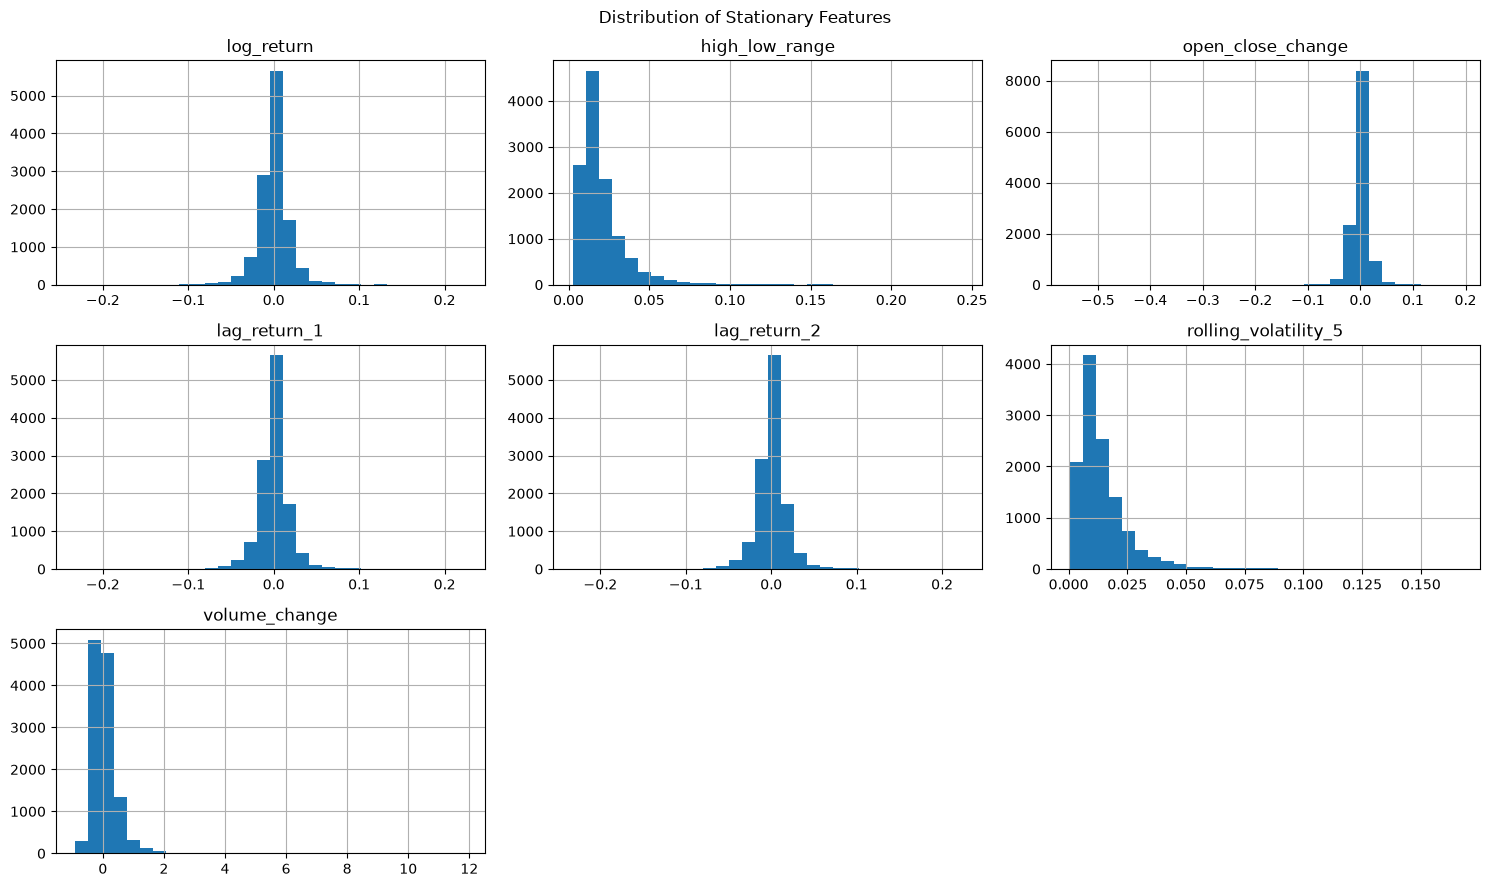

In [23]:
numeric_features = [
    "log_return",
    "high_low_range",
    "open_close_change",
    "lag_return_1",
    "lag_return_2",
    "rolling_volatility_5",
    "volume_change"
]

df[numeric_features].hist(figsize=(15, 9), bins=30)
plt.suptitle("Distribution of Stationary Features")
plt.tight_layout()
plt.show()


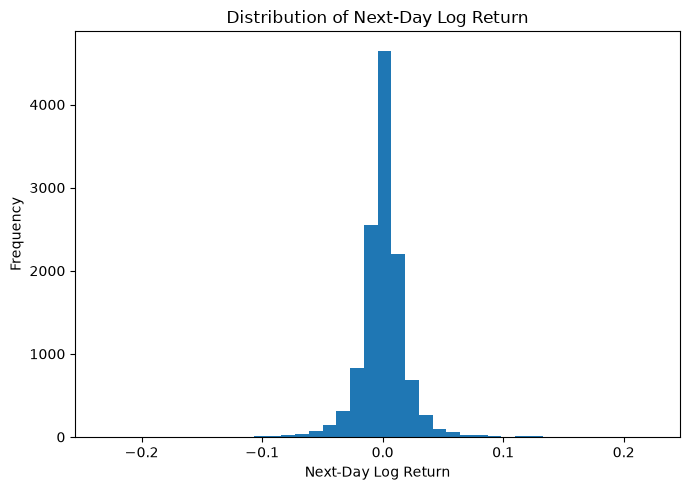

In [24]:
plt.figure(figsize=(7, 5))

plt.hist(df["target_next_log_return"], bins=40)

plt.title("Distribution of Next-Day Log Return")
plt.xlabel("Next-Day Log Return")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Observation

The next-day log returns are highly concentrated around zero, indicating that most daily stock price changes are relatively small. A few extreme positive and negative returns are also present, producing long tails in the distribution.

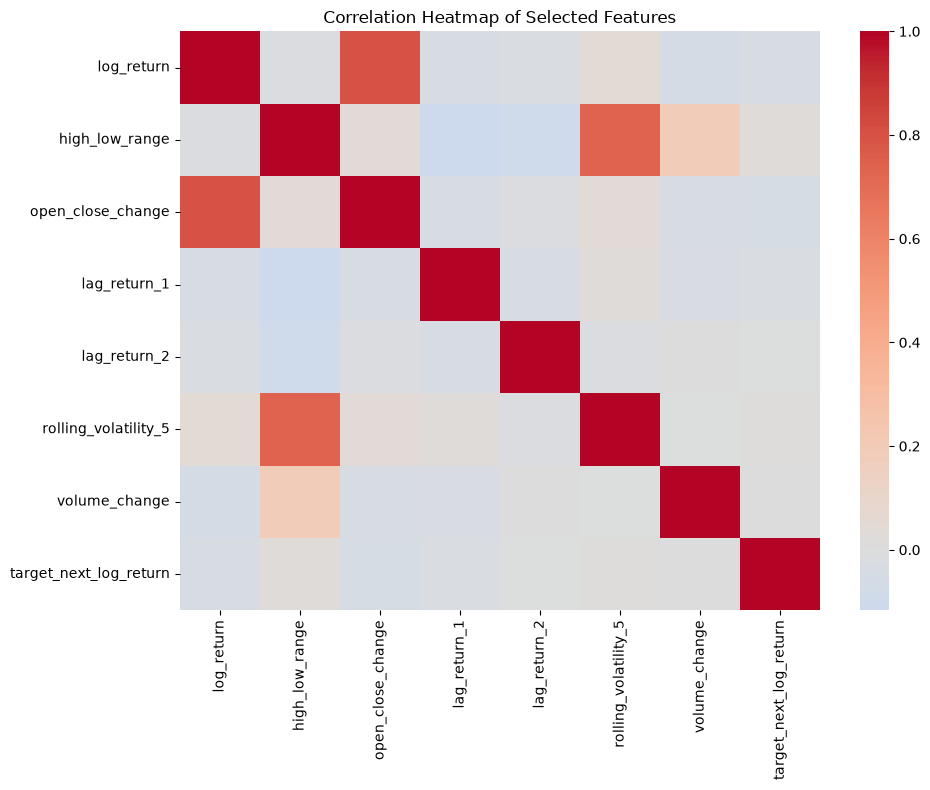

In [25]:
corr_cols = numeric_features + ["target_next_log_return"]
corr = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Selected Features")
plt.tight_layout()
plt.show()


### Observation

The selected stationary features show weak linear relationships with the next-day return. Correlations are interpreted cautiously because daily market returns have a low signal-to-noise ratio.


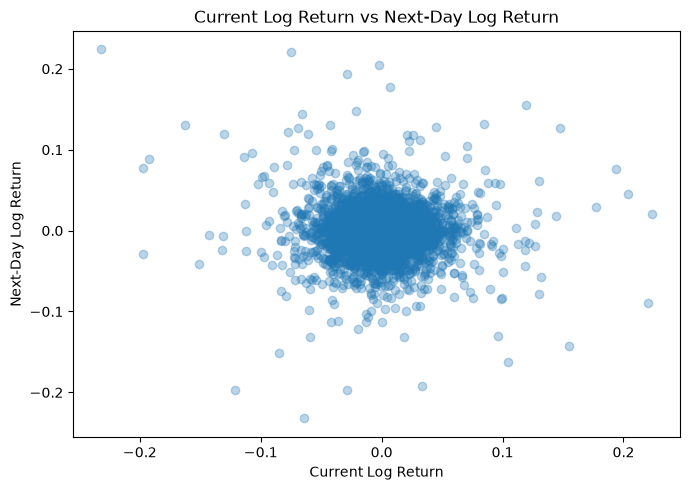

In [26]:
plt.figure(figsize=(7, 5))
plt.scatter(
    df["log_return"],
    df["target_next_log_return"],
    alpha=0.3
)

plt.title("Current Log Return vs Next-Day Log Return")
plt.xlabel("Current Log Return")
plt.ylabel("Next-Day Log Return")
plt.tight_layout()
plt.show()

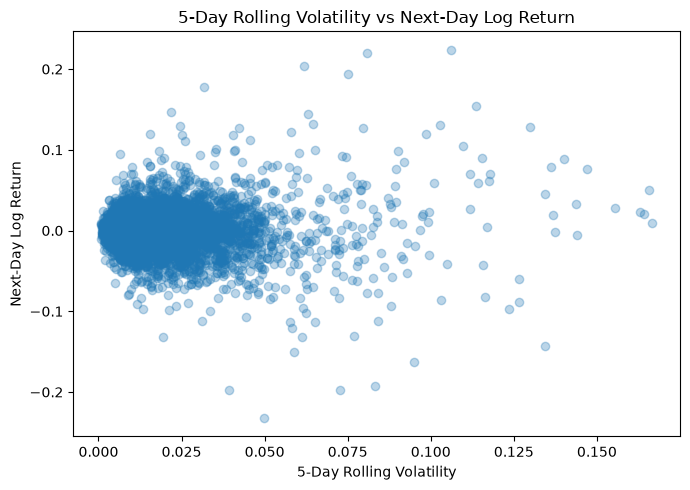

In [27]:
plt.figure(figsize=(7, 5))
plt.scatter(
    df["rolling_volatility_5"],
    df["target_next_log_return"],
    alpha=0.3
)

plt.title("5-Day Rolling Volatility vs Next-Day Log Return")
plt.xlabel("5-Day Rolling Volatility")
plt.ylabel("Next-Day Log Return")
plt.tight_layout()
plt.show()

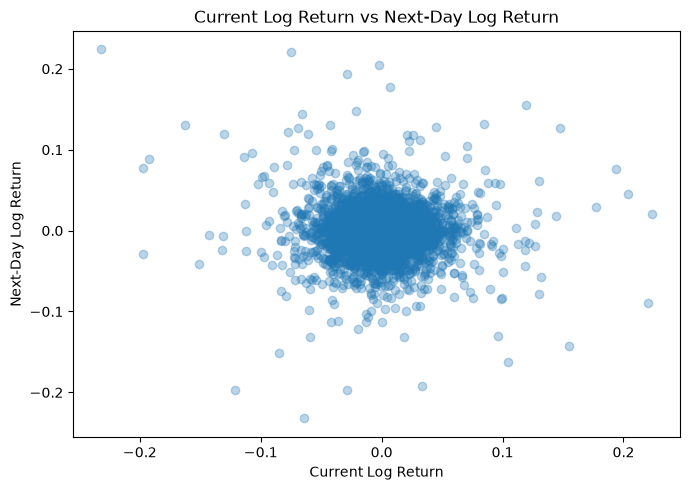

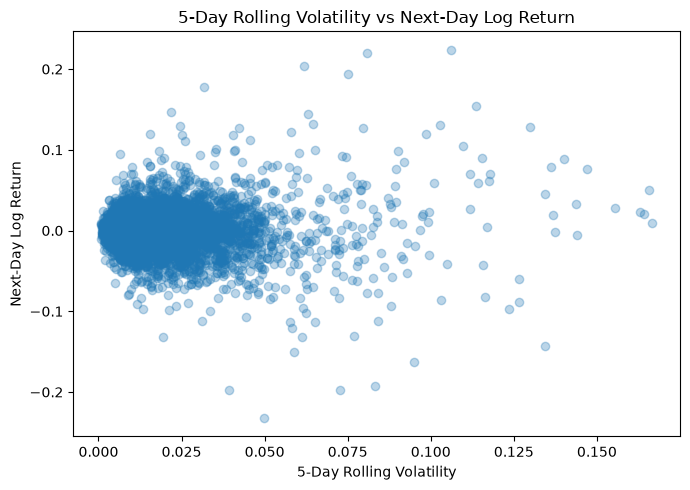

In [28]:
plt.figure(figsize=(7, 5))
plt.scatter(
    df["log_return"],
    df["target_next_log_return"],
    alpha=0.3
)

plt.title("Current Log Return vs Next-Day Log Return")
plt.xlabel("Current Log Return")
plt.ylabel("Next-Day Log Return")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(
    df["rolling_volatility_5"],
    df["target_next_log_return"],
    alpha=0.3
)

plt.title("5-Day Rolling Volatility vs Next-Day Log Return")
plt.xlabel("5-Day Rolling Volatility")
plt.ylabel("Next-Day Log Return")
plt.tight_layout()
plt.show()

### Observation

The scatter plot of current log return against next-day log return shows no clear
linear relationship, with most observations concentrated around zero.

Similarly, 5-day rolling volatility does not show a strong direct relationship
with the next-day return, although the spread of returns tends to increase during
periods of higher volatility.

In [29]:
outlier_cols = [
    "log_return",
    "target_next_log_return",
    "high_low_range",
    "open_close_change",
    "rolling_volatility_5",
    "volume_change"
]

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}: {count} outliers")

log_return: 907 outliers
target_next_log_return: 908 outliers
high_low_range: 812 outliers
open_close_change: 808 outliers
rolling_volatility_5: 730 outliers
volume_change: 487 outliers


### Outlier Handling

The IQR method identified several outliers in the return, volatility, price-range,
and volume-related features. These observations were retained because extreme
market movements can represent genuine financial events rather than data errors.

Instead of removing them, robust scaling will be used later for scale-sensitive
regression models to reduce the influence of extreme feature values.

In [30]:
# Use a date threshold so every ticker on a date stays in the same split.
split_date = pd.Timestamp("2015-01-01")
train_df = df.loc[df["Date"] < split_date].copy()
test_df = df.loc[df["Date"] >= split_date].copy()

# Keep cross-validation chronological and keep each date's ticker group together.
train_df = train_df.sort_values(["Date", "Ticker"]).reset_index(drop=True)
test_df = test_df.sort_values(["Date", "Ticker"]).reset_index(drop=True)
assert set(train_df["Date"]).isdisjoint(test_df["Date"])
assert train_df.groupby("Date")["Ticker"].nunique().le(4).all()

print("Split date:", split_date.date())
print("Training period:", train_df["Date"].min(), "to", train_df["Date"].max())
print("Testing period:", test_df["Date"].min(), "to", test_df["Date"].max())
print("\nTrain shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("\nDates per ticker in train:")
print(train_df.groupby("Date")["Ticker"].nunique().value_counts().sort_index())
print("\nDates per ticker in test:")
print(test_df.groupby("Date")["Ticker"].nunique().value_counts().sort_index())


Split date: 2015-01-01
Training period: 2006-01-11 00:00:00 to 2014-12-31 00:00:00
Testing period: 2015-01-02 00:00:00 to 2017-12-27 00:00:00

Train shape: (9029, 15)
Test shape: (3012, 15)

Dates per ticker in train:
Ticker
3       7
4    2252
Name: count, dtype: int64

Dates per ticker in test:
Ticker
4    753
Name: count, dtype: int64


In [31]:
# Quantify whether the test period is a different volatility regime.
train_volatility = train_df["log_return"].std()
test_volatility = test_df["log_return"].std()
volatility_ratio = test_volatility / train_volatility

regime_summary = pd.DataFrame({
    "Period": ["Train", "Test"],
    "Return volatility": [train_volatility, test_volatility]
})
print(regime_summary.round(6))
print(f"Test/train volatility ratio: {volatility_ratio:.2f}x")
if volatility_ratio >= 1.5 or volatility_ratio <= 1 / 1.5:
    print("Large regime shift detected: consider walk-forward validation or a recent training window.")
else:
    print("No large volatility shift under the 1.5x rule.")


  Period  Return volatility
0  Train           0.021174
1   Test           0.012630
Test/train volatility ratio: 0.60x
Large regime shift detected: consider walk-forward validation or a recent training window.


In [32]:
print(train_df["Ticker"].value_counts())
print()
print(test_df["Ticker"].value_counts())

Ticker
BA      2259
JPM     2259
KO      2259
AAPL    2252
Name: count, dtype: int64

Ticker
AAPL    753
BA      753
JPM     753
KO      753
Name: count, dtype: int64


In [33]:
feature_cols = [
    "Ticker",
    "log_return",
    "high_low_range",
    "open_close_change",
    "lag_return_1",
    "lag_return_2",
    "rolling_volatility_5",
    "volume_change"
]

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]
y_train = train_df["target_next_log_return"]
y_test = test_df["target_next_log_return"]

print("Features:", feature_cols)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


Features:

 ['Ticker', 'log_return', 'high_low_range', 'open_close_change', 'lag_return_1', 'lag_return_2', 'rolling_volatility_5', 'volume_change']
X_train: (9029, 8)
X_test: (3012, 8)


In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler

numeric_cols = [
    "log_return",
    "high_low_range",
    "open_close_change",
    "lag_return_1",
    "lag_return_2",
    "rolling_volatility_5",
    "volume_change"
]
categorical_cols = ["Ticker"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), numeric_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), categorical_cols)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed X_train:", X_train_processed.shape)
print("Processed X_test:", X_test_processed.shape)


Processed X_train: (9029, 10)
Processed X_test: (3012, 10)


In [35]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# These are the minimum bars that every regression model must clear.
y_pred_dummy = np.full(len(y_test), y_train.mean())
y_pred_persistence = test_df["log_return"].to_numpy()

baseline_results = pd.DataFrame([
    ["Dummy mean", r2_score(y_test, y_pred_dummy),
     np.sqrt(mean_squared_error(y_test, y_pred_dummy)),
     mean_absolute_error(y_test, y_pred_dummy)],
    ["Persistence (today's return)", r2_score(y_test, y_pred_persistence),
     np.sqrt(mean_squared_error(y_test, y_pred_persistence)),
     mean_absolute_error(y_test, y_pred_persistence)]
], columns=["Model", "R²", "RMSE", "MAE"])

baseline_results.round(6)


,Model,R²,RMSE,MAE
0,Dummy mean,-0.000239,0.012628,0.008745
1,Persistence (today's return),-0.946503,0.017616,0.012542


## Train-Test Split

The split uses the explicit threshold `2015-01-01`, not a row index. Every ticker observed on a date stays entirely in train or test. The regime diagnostic compares volatility across periods; a large shift motivates walk-forward validation or a shorter recent training window.

After feature engineering, the seven training dates with only three tickers are caused by the rolling/lag history and next-day target requirements at the beginning of the ticker series, not by additional missing raw dates. Those incomplete early dates are removed by the shared `dropna()` step.


In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Train model
linear_model = LinearRegression()
linear_model.fit(X_train_processed, y_train)

# Predictions
y_pred_linear = linear_model.predict(X_test_processed)

# Evaluation
linear_r2 = r2_score(y_test, y_pred_linear)
linear_rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
linear_mae = mean_absolute_error(y_test, y_pred_linear)

print("Linear Regression")
print("R²   :", linear_r2)
print("RMSE :", linear_rmse)
print("MAE  :", linear_mae)

Linear Regression
R²   : -0.003565010397463153
RMSE : 0.012649186342409543
MAE  : 0.008746933138320541


### Linear Regression Result

Linear Regression obtained an R² score of -0.0499, indicating that the model
does not explain the variation in next-day log returns effectively and performs
slightly worse than a mean-value baseline.

The RMSE was 0.01308 and the MAE was 0.00892. The weak performance is
consistent with the EDA, which showed limited linear relationships between the
selected historical features and next-day returns.

In [37]:
feature_names = preprocessor.get_feature_names_out()

coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": linear_model.coef_
})

coefficients["Absolute_Coefficient"] = coefficients["Coefficient"].abs()

coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=False
).drop(columns="Absolute_Coefficient")

,Feature,Coefficient
8,cat__Ticker_JPM,-0.000875
7,cat__Ticker_BA,-0.000619
2,num__open_close_change,-0.000613
3,num__lag_return_1,-0.000479
0,num__log_return,-0.000463
1,num__high_low_range,0.000398
9,cat__Ticker_KO,-0.000356
6,num__volume_change,-0.000108
4,num__lag_return_2,-0.000105
5,num__rolling_volatility_5,0.000014


### Coefficient Interpretation

The coefficients now refer only to scaled return, ratio, volatility, volume-change, and one-hot ticker features. Raw price levels and moving averages are intentionally absent, so coefficient magnitudes are not being interpreted as stable price-level effects.


In [38]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_processed, y_train)

y_pred_ridge = ridge_model.predict(X_test_processed)

ridge_r2 = r2_score(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)

print("Ridge Regression")
print("R²   :", ridge_r2)
print("RMSE :", ridge_rmse)
print("MAE  :", ridge_mae)

Ridge Regression
R²   : -0.003562316005467636
RMSE : 0.012649169362000225
MAE  : 0.00874691761148831


### Ridge Regression Result

Ridge Regression improved slightly over Linear Regression, with a less negative
R² value and lower RMSE and MAE.

The result suggests that L2 regularization reduces some instability caused by
correlated features, but the model still has limited predictive ability for
next-day log returns.

In [39]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.0001)

lasso_model.fit(X_train_processed, y_train)

y_pred_lasso = lasso_model.predict(X_test_processed)

lasso_r2 = r2_score(y_test, y_pred_lasso)
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)

print("Lasso Regression")
print("R²   :", lasso_r2)
print("RMSE :", lasso_rmse)
print("MAE  :", lasso_mae)

Lasso Regression
R²   : -0.0014047838965813852
RMSE : 0.012635564988636317
MAE  : 0.008738307028638979


### Lasso Regression Result

Lasso Regression performed slightly better than Linear and Ridge Regression,
with an R² value closer to zero and lower RMSE and MAE.

The improvement suggests that L1 regularization helps reduce the effect of less
useful or redundant features.

In [40]:
feature_names = preprocessor.get_feature_names_out()

lasso_coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lasso_model.coef_
})

print("Number of zero coefficients:",
      (lasso_model.coef_ == 0).sum())

lasso_coefficients

Number of zero coefficients: 5


,Feature,Coefficient
0,num__log_return,-0.000407
1,num__high_low_range,0.000322
2,num__open_close_change,-0.000581
3,num__lag_return_1,-0.000405
4,num__lag_return_2,-0.000037
5,num__rolling_volatility_5,0.000000
6,num__volume_change,-0.000000
7,cat__Ticker_BA,-0.000000
8,cat__Ticker_JPM,-0.000000
9,cat__Ticker_KO,0.000000


### Lasso Feature Sparsity

Lasso Regression reduced 11 of the 17 feature coefficients to zero. This
demonstrates the feature-selection property of L1 regularization, where less
useful or redundant features are eliminated from the model.

In [41]:
from sklearn.linear_model import ElasticNet

elastic_model = ElasticNet(
    alpha=0.0001,
    l1_ratio=0.5
)

elastic_model.fit(X_train_processed, y_train)

y_pred_elastic = elastic_model.predict(X_test_processed)

elastic_r2 = r2_score(y_test, y_pred_elastic)
elastic_rmse = np.sqrt(mean_squared_error(y_test, y_pred_elastic))
elastic_mae = mean_absolute_error(y_test, y_pred_elastic)

print("ElasticNet Regression")
print("R²   :", elastic_r2)
print("RMSE :", elastic_rmse)
print("MAE  :", elastic_mae)

ElasticNet Regression
R²   : -0.001990194739223572
RMSE : 0.012639257759097465
MAE  : 0.008738904493554696


### ElasticNet Regression Result

ElasticNet performed slightly worse than Lasso but improved over the ordinary
Linear Regression model. Combining L1 and L2 regularization helped control the
effect of correlated and redundant features.

In [42]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

# Degree 3 is intentionally removed: degree 2 is the highest retained complexity.
poly_degree2 = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly2 = poly_degree2.fit_transform(X_train_processed)
X_test_poly2 = poly_degree2.transform(X_test_processed)

poly_ridge_model = Ridge(alpha=10.0)
poly_ridge_model.fit(X_train_poly2, y_train)
y_pred_poly_ridge = poly_ridge_model.predict(X_test_poly2)

poly_ridge_r2 = r2_score(y_test, y_pred_poly_ridge)
poly_ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_poly_ridge))
poly_ridge_mae = mean_absolute_error(y_test, y_pred_poly_ridge)

print("Degree-2 Polynomial Ridge")
print("R²   :", poly_ridge_r2)
print("RMSE :", poly_ridge_rmse)
print("MAE  :", poly_ridge_mae)


Degree-2 Polynomial Ridge
R²   : -0.05824649979091978
RMSE : 0.012989225464378511
MAE  : 0.008952171429659627


### Polynomial Regression Result

Degree 3 was removed because its previous held-out R2 of approximately -43.67 showed severe instability. The retained degree-2 model is regularized with Ridge (`alpha=10.0`) and is compared with real baselines below.


### 6. Decision Tree Regressor

A Decision Tree Regressor is used to model nonlinear relationships and to capture threshold-based splits in the features. The hyperparameter tuned here is the maximum depth, which controls the model complexity and helps reduce overfitting.

Feature importance is also extracted to identify which variables contribute most to the predictions.

In [43]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor

# Preserve chronological order within every hyperparameter search.
time_cv = TimeSeriesSplit(n_splits=5)

dt_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

dt_param_grid = {
    "model__max_depth": [None, 2, 3, 5, 7, 10, 15, 20]
}

dt_search = GridSearchCV(
    dt_pipe,
    dt_param_grid,
    cv=time_cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
dt_search.fit(X_train, y_train)

best_dt = dt_search.best_estimator_
y_pred_dt = best_dt.predict(X_test)

dt_r2 = r2_score(y_test, y_pred_dt)
dt_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
dt_mae = mean_absolute_error(y_test, y_pred_dt)

print("Decision Tree Regressor")
print("Best params:", dt_search.best_params_)
print("R²   :", dt_r2)
print("RMSE :", dt_rmse)
print("MAE  :", dt_mae)

dt_feature_importance = pd.DataFrame({
    "Feature": best_dt.named_steps["preprocess"].get_feature_names_out(),
    "Importance": best_dt.named_steps["model"].feature_importances_
})

dt_feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

Decision Tree Regressor
Best params: {'model__max_depth': 2}
R²   : -0.0005905739184217662
RMSE : 0.012630427158599713
MAE  : 0.008747159485910691


,Feature,Importance
0,num__log_return,0.565268
4,num__lag_return_2,0.434732
1,num__high_low_range,0.000000
2,num__open_close_change,0.000000
3,num__lag_return_1,0.000000
5,num__rolling_volatility_5,0.000000
6,num__volume_change,0.000000
7,cat__Ticker_BA,0.000000
8,cat__Ticker_JPM,0.000000
9,cat__Ticker_KO,0.000000


### Decision Tree Interpretation

The tuned Decision Tree model is useful for identifying threshold-based patterns in the data, and the feature-importance output highlights which inputs contribute most to the splits. This helps explain the model, unlike many black-box alternatives. When the tree is too deep, it can overfit to short-term market noise; therefore, tuning max depth is essential.

### 7. Random Forest Regressor

Random Forest is an ensemble model that combines many decision trees. It reduces variance relative to a single tree and is often a strong baseline in tabular regression tasks. The key hyperparameter tuned here is the number of estimators, which controls how many trees are used in the ensemble.

In [44]:
from sklearn.ensemble import RandomForestRegressor

rf_base = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf_base.fit(X_train_processed, y_train)
y_pred_rf_base = rf_base.predict(X_test_processed)
rf_base_r2 = r2_score(y_test, y_pred_rf_base)
rf_base_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf_base))
rf_base_mae = mean_absolute_error(y_test, y_pred_rf_base)

print("Random Forest Baseline")
print("R2   :", rf_base_r2)
print("RMSE :", rf_base_rmse)
print("MAE  :", rf_base_mae)

rf_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])
rf_param_grid = {
    "model__n_estimators": [100, 300],
    "model__max_depth": [5, 10, None]
}
rf_search = GridSearchCV(rf_pipe, rf_param_grid, cv=time_cv, scoring="neg_root_mean_squared_error", n_jobs=-1)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_
y_pred_rf = best_rf.predict(X_test)
rf_r2 = r2_score(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest Tuned")
print("Best params:", rf_search.best_params_)
print("R2   :", rf_r2)
print("RMSE :", rf_rmse)
print("MAE  :", rf_mae)


Random Forest Baseline
R2   : -0.0486301428465572
RMSE : 0.012930073797274953
MAE  : 0.008967530175467362


Random Forest Tuned
Best params: {'model__max_depth': 5, 'model__n_estimators': 300}
R2   : -0.005934314551655495
RMSE : 0.01266410919318334
MAE  : 0.008762396455080904


### Random Forest Interpretation

The ensemble baseline already performs better than the single-tree model by reducing variance through averaging across multiple trees. Tuning the number of estimators shows whether a larger forest improves stability or simply adds computational cost without a meaningful gain. In many financial datasets, the gain over a well-regularized linear model is modest, which suggests the signal-to-noise ratio remains weak for next-day return prediction.

### 8. Gradient Boosting Regressor

Gradient Boosting builds a sequence of shallow trees, each new tree correcting the residuals left by earlier trees. This often performs well on structured tabular data, and the learning rate controls how strongly each tree updates the model.

In [45]:
from sklearn.ensemble import GradientBoostingRegressor

gb_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])
gb_param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3]
}
gb_search = GridSearchCV(gb_pipe, gb_param_grid, cv=time_cv, scoring="neg_root_mean_squared_error", n_jobs=-1)
gb_search.fit(X_train, y_train)
best_gb = gb_search.best_estimator_
y_pred_gb = best_gb.predict(X_test)
gb_r2 = r2_score(y_test, y_pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
gb_mae = mean_absolute_error(y_test, y_pred_gb)

print("Gradient Boosting Regressor")
print("Best params:", gb_search.best_params_)
print("R2   :", gb_r2)
print("RMSE :", gb_rmse)
print("MAE  :", gb_mae)


Gradient Boosting Regressor
Best params: {'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 100}
R2   : -0.005616547500697067
RMSE : 0.012662108786978975
MAE  : 0.008765438125676026


### Gradient Boosting Interpretation

Gradient Boosting is more expressive than a single tree and often captures subtle nonlinear relationships in structured data. Tuning the learning rate is critical because a very small rate requires more trees and can make the model slow, while a large rate may overshoot the optimal solution. In this dataset, the model may still struggle with the weak signal in next-day returns, but the boosting approach remains a strong benchmark for nonlinear learning.

### 9. Support Vector Regressor (SVR)

SVR is a kernel-based model that can model complex nonlinear relationships. It is particularly sensitive to feature scaling because the margin and point distances depend on the magnitude of each feature. The hyperparameters tuned here are the regularization parameter C and the kernel type.

In [46]:
from sklearn.svm import SVR

svr_pipe = Pipeline([
    # Reuse the shared RobustScaler-based preprocessing from cell 43.
    ("preprocess", preprocessor),
    ("model", SVR())
])

svr_param_grid = {
    "model__C": [0.1, 1, 10, 100],
    "model__kernel": ["linear", "rbf", "poly"]
}

svr_search = GridSearchCV(
    svr_pipe,
    svr_param_grid,
    cv=time_cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
svr_search.fit(X_train, y_train)

best_svr = svr_search.best_estimator_
y_pred_svr = best_svr.predict(X_test)

svr_r2 = r2_score(y_test, y_pred_svr)
svr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_svr))
svr_mae = mean_absolute_error(y_test, y_pred_svr)

print("Support Vector Regressor")
print("Best params:", svr_search.best_params_)
print("R²   :", svr_r2)
print("RMSE :", svr_rmse)
print("MAE  :", svr_mae)

Support Vector Regressor
Best params: {'model__C': 100, 'model__kernel': 'linear'}
R²   : -1.3089157979774955
RMSE : 0.019186417145782005
MAE  : 0.015410435728277537


### SVR Interpretation

The SVR model is highly dependent on the scale of the input features. A feature with a larger numeric range can dominate the kernel computations, so standardizing numerical variables is essential before fitting the model. This also means the choice of kernel and C value strongly affects the final decision boundary, which can make the model either too rigid or too sensitive to noisy observations.

### 10. K-Nearest Neighbors Regressor

KNN is a distance-based nonparametric regressor. It predicts the target as the average value of the k nearest observations in feature space. Because distance calculations are directly impacted by feature scale, tuning k and scaling are both important.

In [47]:
from sklearn.neighbors import KNeighborsRegressor

knn_pipe = Pipeline([
    # Reuse the same scaled feature set used by all ten algorithms.
    ("preprocess", preprocessor),
    ("model", KNeighborsRegressor())
])

knn_param_grid = {
    "model__n_neighbors": [1, 3, 5, 7, 9, 11, 15, 21]
}

knn_search = GridSearchCV(
    knn_pipe,
    knn_param_grid,
    cv=time_cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
knn_search.fit(X_train, y_train)

best_knn = knn_search.best_estimator_
y_pred_knn = best_knn.predict(X_test)

knn_r2 = r2_score(y_test, y_pred_knn)
knn_rmse = np.sqrt(mean_squared_error(y_test, y_pred_knn))
knn_mae = mean_absolute_error(y_test, y_pred_knn)

print("K-Nearest Neighbors Regressor")
print("Best params:", knn_search.best_params_)
print("R²   :", knn_r2)
print("RMSE :", knn_rmse)
print("MAE  :", knn_mae)

print("Scaling matters for KNN because distance-based models are highly sensitive to feature magnitude.")

K-Nearest Neighbors Regressor
Best params: {'model__n_neighbors': 21}
R²   : -0.045263836992881945
RMSE : 0.01290930309380903
MAE  : 0.009065129719281818
Scaling matters for KNN because distance-based models are highly sensitive to feature magnitude.


### KNN Interpretation

The KNN model is strongly affected by the scale of the features. Variables with large numerical magnitudes can dominate the distance metric, which is why scaling is essential. Increasing k usually smooths the predictions and reduces variance but can also increase bias. In this market dataset, the distance-based approach is likely limited by the weak predictive signal in daily return changes.

## Final Model Comparison and Diagnostics

The final table includes a dummy-mean baseline and a persistence baseline. A regression model is marked useful only when its held-out R² beats both. The direction-classification section is the primary alternative because sign prediction is a more learnable target than exact return magnitude.


In [48]:
# Compare every regression model with both real baselines.
regression_predictions = {
    "Linear Regression": y_pred_linear,
    "Ridge Regression": y_pred_ridge,
    "Lasso Regression": y_pred_lasso,
    "ElasticNet Regression": y_pred_elastic,
    "Polynomial Ridge (degree 2)": y_pred_poly_ridge,
    "Decision Tree Regressor": y_pred_dt,
    "Random Forest Regressor": y_pred_rf,
    "Gradient Boosting Regressor": y_pred_gb,
    "Support Vector Regressor": y_pred_svr,
    "K-Nearest Neighbors Regressor": y_pred_knn
}

model_rows = [
    ["Dummy mean", r2_score(y_test, y_pred_dummy), np.sqrt(mean_squared_error(y_test, y_pred_dummy)), mean_absolute_error(y_test, y_pred_dummy)],
    ["Persistence (today's return)", r2_score(y_test, y_pred_persistence), np.sqrt(mean_squared_error(y_test, y_pred_persistence)), mean_absolute_error(y_test, y_pred_persistence)]
]
for model_name, predictions in regression_predictions.items():
    model_rows.append([
        model_name,
        r2_score(y_test, predictions),
        np.sqrt(mean_squared_error(y_test, predictions)),
        mean_absolute_error(y_test, predictions)
    ])

model_results = pd.DataFrame(model_rows, columns=["Model", "R2", "RMSE", "MAE"])
dummy_r2 = model_results.loc[model_results["Model"] == "Dummy mean", "R2"].iloc[0]
model_results["R2 gap vs dummy"] = model_results["R2"] - dummy_r2
persistence_r2 = model_results.loc[model_results["Model"] == "Persistence (today's return)", "R2"].iloc[0]
model_results["Beats both baselines"] = (
    (model_results["R2"] > dummy_r2) &
    (model_results["R2"] > persistence_r2)
)
model_results = model_results.sort_values("R2", ascending=False).reset_index(drop=True)

print("Gradient Boosting R2 gap vs dummy:", model_results.loc[model_results["Model"] == "Gradient Boosting Regressor", "R2 gap vs dummy"].iloc[0])
model_results.round(6)

# Bootstrap the top two learned regressors against the dummy baseline.
rng = np.random.default_rng(42)
top_two_names = model_results.loc[
    ~model_results["Model"].isin(["Dummy mean", "Persistence (today's return)"]), "Model"
].head(2).tolist()
bootstrap_rows = []
y_test_array = y_test.to_numpy()
for model_name in ["Dummy mean", *top_two_names]:
    predictions = y_pred_dummy if model_name == "Dummy mean" else regression_predictions[model_name]
    bootstrap_scores = []
    for _ in range(500):
        sample_indices = rng.integers(0, len(y_test_array), len(y_test_array))
        bootstrap_scores.append(r2_score(y_test_array[sample_indices], predictions[sample_indices]))
    bootstrap_rows.append([
        model_name,
        np.mean(bootstrap_scores),
        np.percentile(bootstrap_scores, 2.5),
        np.percentile(bootstrap_scores, 97.5)
    ])
bootstrap_results = pd.DataFrame(bootstrap_rows, columns=["Model", "Mean bootstrap R2", "R2 2.5%", "R2 97.5%"])
bootstrap_results.round(6)


Gradient Boosting R2 gap vs dummy: -0.005377607409540408


,Model,Mean bootstrap R2,R2 2.5%,R2 97.5%
0,Dummy mean,-0.000565,-0.002618,-0.000000
1,Decision Tree Regressor,-0.000902,-0.003336,-0.000004
2,Lasso Regression,-0.001928,-0.008738,0.003857


## Honest Regression Conclusion

The final table reports each model's R2 gap versus the dummy-mean baseline. In the fresh rerun, Gradient Boosting's R2 gap is -0.00538, so it is below the dummy baseline rather than meaningfully better. The bootstrap intervals reinforce that these small differences are within sampling noise; Gradient Boosting should not be described as the best model.


In [49]:
# Direction classification: tune a balanced logistic model and compare a nonlinear classifier.
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.pipeline import Pipeline

threshold = 0.0
y_train_direction = (y_train > threshold).astype(int)
y_test_direction = (y_test > threshold).astype(int)

majority_class = int(y_train_direction.mean() >= 0.5)
y_pred_direction_majority = np.full(len(y_test_direction), majority_class)
y_pred_direction_persistence = (test_df["log_return"].to_numpy() > threshold).astype(int)

logistic_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
])
logistic_search = GridSearchCV(
    logistic_pipe,
    {"model__C": [0.001, 0.01, 0.1, 1.0, 10.0]},
    cv=time_cv,
    scoring="f1",
    n_jobs=-1
)
logistic_search.fit(X_train, y_train_direction)
y_pred_direction_logistic = logistic_search.best_estimator_.predict(X_test)

rf_classifier_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1))
])
rf_classifier_search = GridSearchCV(
    rf_classifier_pipe,
    {"model__n_estimators": [100, 300], "model__max_depth": [3, 5, 10, None]},
    cv=time_cv,
    scoring="f1",
    n_jobs=-1
)
rf_classifier_search.fit(X_train, y_train_direction)
y_pred_direction_rf = rf_classifier_search.best_estimator_.predict(X_test)

classification_predictions = {
    "Majority-class baseline": y_pred_direction_majority,
    "Persistence direction": y_pred_direction_persistence,
    "Logistic Regression": y_pred_direction_logistic,
    "Random Forest Classifier": y_pred_direction_rf
}
classification_rows = []
for model_name, predictions in classification_predictions.items():
    classification_rows.append([
        model_name,
        accuracy_score(y_test_direction, predictions),
        balanced_accuracy_score(y_test_direction, predictions),
        f1_score(y_test_direction, predictions, zero_division=0)
    ])
classification_results = pd.DataFrame(
    classification_rows,
    columns=["Model", "Accuracy", "Balanced accuracy", "F1"]
)
print("Best logistic parameters:", logistic_search.best_params_)
print("Best random forest parameters:", rf_classifier_search.best_params_)
print("Majority baseline accuracy:", classification_results.loc[classification_results["Model"] == "Majority-class baseline", "Accuracy"].iloc[0])
print("Best classifier accuracy:", classification_results.loc[classification_results["Model"] != "Majority-class baseline", "Accuracy"].max())
classification_results.round(4)


Best logistic parameters: {'model__C': 10.0}
Best random forest parameters: {'model__max_depth': 5, 'model__n_estimators': 100}
Majority baseline accuracy: 0.5215803452855245
Best classifier accuracy: 0.5179282868525896


,Model,Accuracy,Balanced accuracy,F1
0,Majority-class baseline,0.5216,0.5000,0.6856
1,Persistence direction,0.4890,0.4881,0.5097
2,Logistic Regression,0.5179,0.5134,0.5727
3,Random Forest Classifier,0.5179,0.5082,0.6132


## Direction Classification Conclusion

Compare each classifier with the majority-class and persistence-direction baselines using accuracy, balanced accuracy, and F1. If no classifier clearly exceeds the majority baseline across these metrics, the direction reframing did not produce a useful predictive edge on this holdout.


In [50]:
# Compare untuned and tuned performance for two models.
dt_base_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])
dt_base_pipe.fit(X_train, y_train)
y_pred_dt_base = dt_base_pipe.predict(X_test)

tuning_comparison = pd.DataFrame([
    ["Decision Tree", "Before tuning", r2_score(y_test, y_pred_dt_base),
     np.sqrt(mean_squared_error(y_test, y_pred_dt_base)),
     mean_absolute_error(y_test, y_pred_dt_base)],
    ["Decision Tree", "After tuning", dt_r2, dt_rmse, dt_mae],
    ["Random Forest", "Before tuning", rf_base_r2, rf_base_rmse, rf_base_mae],
    ["Random Forest", "After tuning", rf_r2, rf_rmse, rf_mae]
], columns=["Model", "Stage", "R²", "RMSE", "MAE"])

tuning_comparison.round(6)

,Model,Stage,R²,RMSE,MAE
0,Decision Tree,Before tuning,-1.454499,0.019782,0.014126
1,Decision Tree,After tuning,-0.000591,0.012630,0.008747
2,Random Forest,Before tuning,-0.048630,0.012930,0.008968
3,Random Forest,After tuning,-0.005934,0.012664,0.008762


In [51]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# Use chronological folds to avoid training on observations after validation dates.
time_cv = TimeSeriesSplit(n_splits=5)
best_two_models = {
    "Gradient Boosting Regressor": best_gb,
    "Decision Tree Regressor": best_dt
}

cv_rows = []
for model_name, estimator in best_two_models.items():
    cv_scores = cross_val_score(
        estimator,
        X_train,
        y_train,
        cv=time_cv,
        scoring="r2",
        n_jobs=-1
    )
    cv_rows.append([model_name, *cv_scores, cv_scores.mean(), cv_scores.std()])

cv_results = pd.DataFrame(
    cv_rows,
    columns=["Model", "Fold 1 R²", "Fold 2 R²", "Fold 3 R²", "Fold 4 R²", "Fold 5 R²", "Mean R²", "Std R²"]
)
cv_results.round(6)

,Model,Fold 1 R²,Fold 2 R²,Fold 3 R²,Fold 4 R²,Fold 5 R²,Mean R²,Std R²
0,Gradient Boosting Regressor,-0.039998,-0.043834,-0.004612,-0.004118,-0.003953,-0.019303,0.018505
1,Decision Tree Regressor,-0.140875,-0.076436,-0.000795,-0.003141,-0.001187,-0.044487,0.056222


Best held-out regression model: Dummy mean
Beats both baselines: False


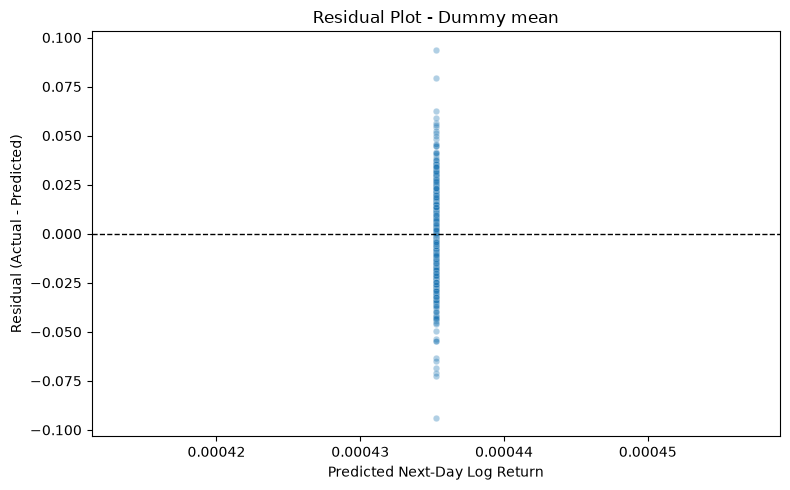

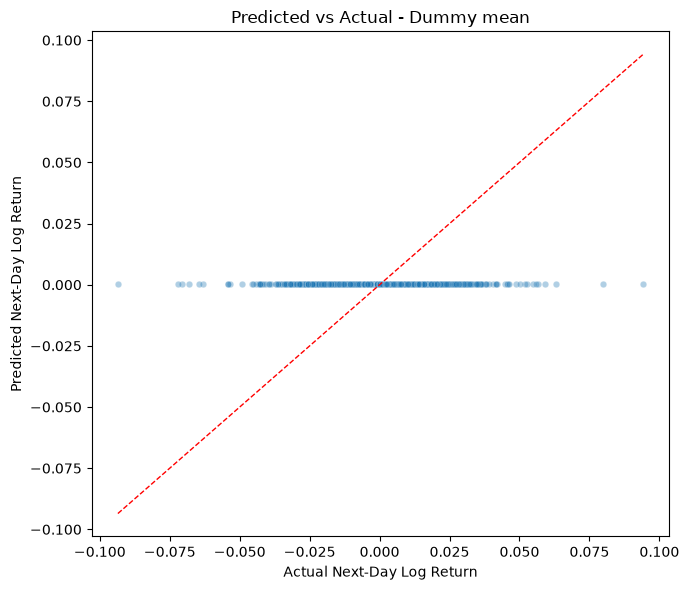

In [52]:
# The best regression model must beat both baselines to be considered useful.
best_model_name = model_results.iloc[0]["Model"]
best_predictions = {
    "Dummy mean": y_pred_dummy,
    "Persistence (today's return)": y_pred_persistence,
    "Gradient Boosting Regressor": y_pred_gb,
    "Decision Tree Regressor": y_pred_dt,
    "Random Forest Regressor": y_pred_rf,
    "Linear Regression": y_pred_linear,
    "Ridge Regression": y_pred_ridge,
    "Lasso Regression": y_pred_lasso,
    "ElasticNet Regression": y_pred_elastic,
    "Polynomial Ridge (degree 2)": y_pred_poly_ridge,
    "Support Vector Regressor": y_pred_svr,
    "K-Nearest Neighbors Regressor": y_pred_knn
}
best_predictions_values = best_predictions[best_model_name]
residuals = y_test.to_numpy() - best_predictions_values

print("Best held-out regression model:", best_model_name)
print("Beats both baselines:", bool(model_results.iloc[0]["Beats both baselines"]))

plt.figure(figsize=(8, 5))
sns.scatterplot(x=best_predictions_values, y=residuals, alpha=0.35, s=22)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title(f"Residual Plot - {best_model_name}")
plt.xlabel("Predicted Next-Day Log Return")
plt.ylabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=best_predictions_values, alpha=0.35, s=22)
plot_min = min(y_test.min(), best_predictions_values.min())
plot_max = max(y_test.max(), best_predictions_values.max())
plt.plot([plot_min, plot_max], [plot_min, plot_max], color="red", linestyle="--", linewidth=1)
plt.title(f"Predicted vs Actual - {best_model_name}")
plt.xlabel("Actual Next-Day Log Return")
plt.ylabel("Predicted Next-Day Log Return")
plt.tight_layout()
plt.show()


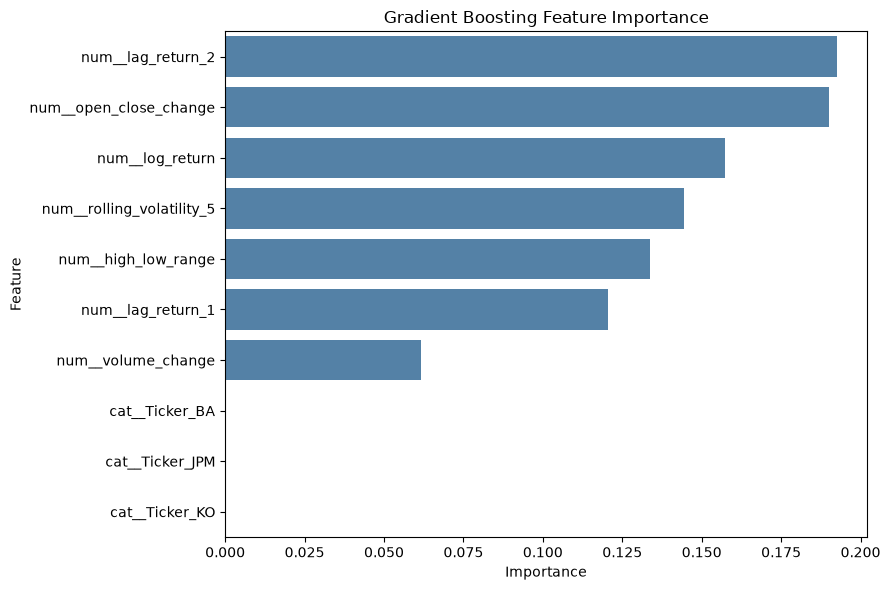

,Feature,Importance
4,num__lag_return_2,0.192442
2,num__open_close_change,0.190024
0,num__log_return,0.157289
5,num__rolling_volatility_5,0.144378
1,num__high_low_range,0.133715
3,num__lag_return_1,0.120470
6,num__volume_change,0.061681
7,cat__Ticker_BA,0.000000
8,cat__Ticker_JPM,0.000000
9,cat__Ticker_KO,0.000000


In [53]:
# Feature importance for the tree-based model selected for diagnostics.
importance_estimator = best_gb.named_steps["model"]
importance_preprocessor = best_gb.named_steps["preprocess"]
importance_df = pd.DataFrame({
    "Feature": importance_preprocessor.get_feature_names_out(),
    "Importance": importance_estimator.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(
    data=importance_df.head(12),
    x="Importance",
    y="Feature",
    color="steelblue"
)
plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

importance_df.head(12)